In [1]:
from transformers import MBartForConditionalGeneration, MBart50TokenizerFast

# Load the saved model and tokenizer
model_path = "/content/drive/MyDrive/mbart-lora-nepali"  # Change this to your actual model path
model = MBartForConditionalGeneration.from_pretrained(model_path)
tokenizer = MBart50TokenizerFast.from_pretrained(model_path)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.44G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/519 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie model.shared.weight to model.encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/261 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/144 [00:00<?, ?it/s]

In [2]:
def generate_summary(model, tokenizer, text: str, max_length: int = 150, num_beams: int = 5) -> str:

    inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True)
    summary_ids = model.generate(**inputs, max_length=max_length, num_beams=num_beams, early_stopping=True,repetition_penalty=2.0,no_repeat_ngram_size=3)
    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [12]:
input_text = "नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्व रहेको छ। यो देशमा हिमाल, पहाड, तराई गरी तीनवटा भौगोलिक क्षेत्रहरू छन्। संसारकै अग्लो हिमाल सगरमाथा नेपालमा अवस्थित छ, जसले पर्यटकहरूलाई आकर्षित गर्छ। यसबाहेक, नेपाल विभिन्न धार्मिक तथा सांस्कृतिक स्थलहरूका कारण पनि प्रसिद्ध छ। पशुपतिनाथ मन्दिर, लुम्बिनी (गौतम बुद्ध जन्मस्थल), स्वयम्भूनाथ, र भक्तपुर दरबार क्षेत्र जस्ता स्थानहरू धार्मिक तथा ऐतिहासिक रूपमा महत्वपूर्ण छन्। नेपाल बहुसांस्कृतिक र बहुभाषिक राष्ट्र हो, जहाँ विभिन्न जाति, भाषा र धर्मका मानिसहरू मिलेर बसेका छन्। यहाँका मुख्य चाडपर्वहरू दशैँ, तिहार, होली, ल्होसार, छठ, र तीज हुन्। कृषि नेपालका धेरैजसो जनताको मुख्य पेशा हो, यद्यपि पर्यटन, उद्योग र व्यापारले पनि अर्थतन्त्रमा योगदान पुऱ्याएका छन्। नेपाल सरकार लोकतान्त्रिक गणतन्त्र प्रणालीमा आधारित छ, जसमा संघीय, प्रदेश, र स्थानीय सरकारको संरचना रहेको छ।"
summary = generate_summary(model, tokenizer, input_text)
print("Summary:", summary)

Summary: नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्व रहेको छ। हिमाल, पहाड, तराई गरी तीन भौगोलिक क्षेत्रहरू रहेका छन्, जसमा संसारकै अग्लो हिमाल सगरमाथा पनि अवस्थित छ। पशुपतिनाथ मन्दिर, लुम्बिनी (गौतम बुद्ध जन्मस्थल), स्वयम्भूनाथ, भक्तपुर दरबार क्षेत्र जस्ता स्थानहरू धार्मिक तथा ऐतिहासिक रूपमा महत्वपूर्ण छन्। नेपाल बहुसांस्कृतिक र बहुभाषिक राष्ट्र हो, जहाँ विभिन्न जाति, भाषा र धर्मका मानिसहरू मिलेर बसेका छन्। यहाँका मुख्य चाडपर्वहरू दशैँ, तिहार, होली, ल्होसार, छठ र तीज हुन्।


In [ ]:
input_text = "त्यसै गरी विश्वको कुनाकुनामा सान्तिको सन्देष छरी अमरवन पुगेका सान्तिका अग्रदुध गोग्व्धमबुद्ध पनि मेरे देशका बासिन्धा हुन्।"
summary = generate_summary(model, tokenizer, input_text)
print("Summary:", summary)

Summary: विश्वको कुनाकुनामा सान्तिको सन्देष छरी अमरवन पुगेका गोग्व्धमबुद्ध पनि मेरे देशका बासिन्धा हुन्।


In [13]:
input_text

'नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्व रहेको छ। यो देशमा हिमाल, पहाड, तराई गरी तीनवटा भौगोलिक क्षेत्रहरू छन्। संसारकै अग्लो हिमाल सगरमाथा नेपालमा अवस्थित छ, जसले पर्यटकहरूलाई आकर्षित गर्छ। यसबाहेक, नेपाल विभिन्न धार्मिक तथा सांस्कृतिक स्थलहरूका कारण पनि प्रसिद्ध छ। पशुपतिनाथ मन्दिर, लुम्बिनी (गौतम बुद्ध जन्मस्थल), स्वयम्भूनाथ, र भक्तपुर दरबार क्षेत्र जस्ता स्थानहरू धार्मिक तथा ऐतिहासिक रूपमा महत्वपूर्ण छन्। नेपाल बहुसांस्कृतिक र बहुभाषिक राष्ट्र हो, जहाँ विभिन्न जाति, भाषा र धर्मका मानिसहरू मिलेर बसेका छन्। यहाँका मुख्य चाडपर्वहरू दशैँ, तिहार, होली, ल्होसार, छठ, र तीज हुन्। कृषि नेपालका धेरैजसो जनताको मुख्य पेशा हो, यद्यपि पर्यटन, उद्योग र व्यापारले पनि अर्थतन्त्रमा योगदान पुऱ्याएका छन्। नेपाल सरकार लोकतान्त्रिक गणतन्त्र प्रणालीमा आधारित छ, जसमा संघीय, प्रदेश, र स्थानीय सरकारको संरचना रहेको छ।'

In [14]:
summary

'नेपाल एक सुन्दर देश हो जसको प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्व रहेको छ। हिमाल, पहाड, तराई गरी तीन भौगोलिक क्षेत्रहरू रहेका छन्, जसमा संसारकै अग्लो हिमाल सगरमाथा पनि अवस्थित छ। पशुपतिनाथ मन्दिर, लुम्बिनी (गौतम बुद्ध जन्मस्थल), स्वयम्भूनाथ, भक्तपुर दरबार क्षेत्र जस्ता स्थानहरू धार्मिक तथा ऐतिहासिक रूपमा महत्वपूर्ण छन्। नेपाल बहुसांस्कृतिक र बहुभाषिक राष्ट्र हो, जहाँ विभिन्न जाति, भाषा र धर्मका मानिसहरू मिलेर बसेका छन्। यहाँका मुख्य चाडपर्वहरू दशैँ, तिहार, होली, ल्होसार, छठ र तीज हुन्।'

In [ ]:
!pip install rouge-score
!pip install rouge # Install the 'rouge' package

from rouge_score import rouge_scorer
from rouge import Rouge  # Now this import should work

# Reference (gold) summary
reference_summary = "नेपाल प्राकृतिक सौन्दर्य, संस्कृतिक विविधता र ऐतिहासिक महत्त्वले भरिएको देश हो। यहाँ हिमाल, पहाड, तराई गरी तीन भौगोलिक क्षेत्रहरू छन्। सगरमाथा, पशुपतिनाथ, लुम्बिनी, र भक्तपुर दरबार क्षेत्र जस्ता स्थलहरूले पर्यटकलाई आकर्षित गर्छन्। नेपाल बहुसांस्कृतिक राष्ट्र हो, जहाँ विभिन्न भाषा, धर्म, र जातिका मानिसहरू बस्छन्। प्रमुख चाडपर्वहरू दशैँ, तिहार, र तीज हुन्। कृषि मुख्य पेशा भए पनि पर्यटन, उद्योग, र व्यापारले अर्थतन्त्रमा योगदान गर्छ। नेपालको शासन व्यवस्था लोकतान्त्रिक गणतन्त्र हो।"

# Predicted summary
predicted_summary =summary
import unicodedata
reference_summary = unicodedata.normalize("NFKC", reference_summary)
predicted_summary = unicodedata.normalize("NFKC", predicted_summary)

rouge = Rouge()
scores = rouge.get_scores(predicted_summary, reference_summary)
print(scores)

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24935 sha256=093fcb648e0636838253573371ad9f182744ca68cc8da125eb5bcf5ad45637b8
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge-score
[{'rouge-1': {'r': 0.5714285714285714, 'p': 0.5070422535211268, 'f': 0.5373134278536422}, 'rouge-2': {'r': 0.3235294117647059, 'p': 0.27848101265822783, 'f': 0.29931972291915415}, 'rouge-l': {'r': 0.5079365079365079, 'p': 0.4507042253521127, 'f': 0.4776119353163288}}]


In [ ]:
scores

[{'rouge-1': {'r': 0.5714285714285714,
   'p': 0.5070422535211268,
   'f': 0.5373134278536422},
  'rouge-2': {'r': 0.3235294117647059,
   'p': 0.27848101265822783,
   'f': 0.29931972291915415},
  'rouge-l': {'r': 0.5079365079365079,
   'p': 0.4507042253521127,
   'f': 0.4776119353163288}}]

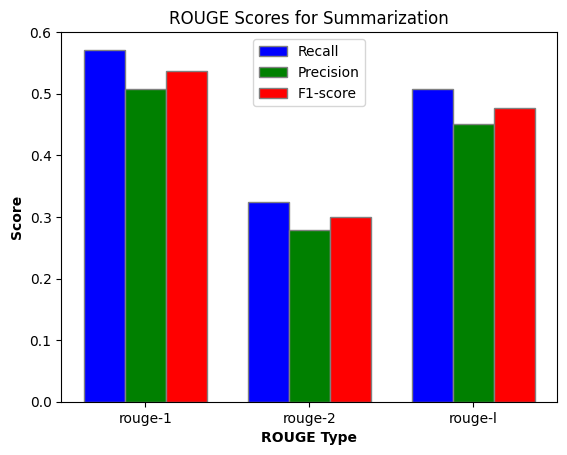

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Your ROUGE scores
scores = [{'rouge-1': {'r': 0.5714285714285714, 'p': 0.5070422535211268, 'f': 0.5373134278536422}, 'rouge-2': {'r': 0.3235294117647059, 'p': 0.27848101265822783, 'f': 0.29931972291915415}, 'rouge-l': {'r': 0.5079365079365079, 'p': 0.4507042253521127, 'f': 0.4776119353163288}}]

# Extract ROUGE scores for plotting
rouge_types = ['rouge-1', 'rouge-2', 'rouge-l']
recall_scores = [scores[0][rouge_type]['r'] for rouge_type in rouge_types]
precision_scores = [scores[0][rouge_type]['p'] for rouge_type in rouge_types]
f1_scores = [scores[0][rouge_type]['f'] for rouge_type in rouge_types]

# Set up the bar plot
barWidth = 0.25
r1 = np.arange(len(rouge_types))
r2 = [x + barWidth for x in r1]
r3 = [x + barWidth for x in r2]

# Create the bars
plt.bar(r1, recall_scores, color='b', width=barWidth, edgecolor='grey', label='Recall')
plt.bar(r2, precision_scores, color='g', width=barWidth, edgecolor='grey', label='Precision')
plt.bar(r3, f1_scores, color='r', width=barWidth, edgecolor='grey', label='F1-score')

# Add labels and title
plt.xlabel('ROUGE Type', fontweight='bold')
plt.ylabel('Score', fontweight='bold')
plt.xticks([r + barWidth for r in range(len(rouge_types))], rouge_types)
plt.title('ROUGE Scores for Summarization')

# Add legend
plt.legend()

# Show the plot
plt.show()